<a href="https://colab.research.google.com/github/TR2Theo/fft-case-studies-template/blob/main/1.1Sunspot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wget https://github.com/TR2Theo/fft-case-studies-template/blob/main/data/sunspots.csv

--2026-05-28 06:33:31--  https://github.com/TR2Theo/fft-case-studies-template/blob/main/data/sunspots.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘sunspots.csv.1’

sunspots.csv.1          [ <=>                ] 621.48K  --.-KB/s    in 0.1s    

2026-05-28 06:33:32 (4.70 MB/s) - ‘sunspots.csv.1’ saved [636391]



--2026-05-28 07:33:04--  https://raw.githubusercontent.com/TR2Theo/fft-case-studies-template/main/data/sunspots.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71184 (70K) [text/plain]
Saving to: ‘sunspots.csv’

sunspots.csv        100%[===================>]  69.52K  --.-KB/s    in 0.01s   

2026-05-28 07:33:04 (5.42 MB/s) - ‘sunspots.csv’ saved [71184/71184]



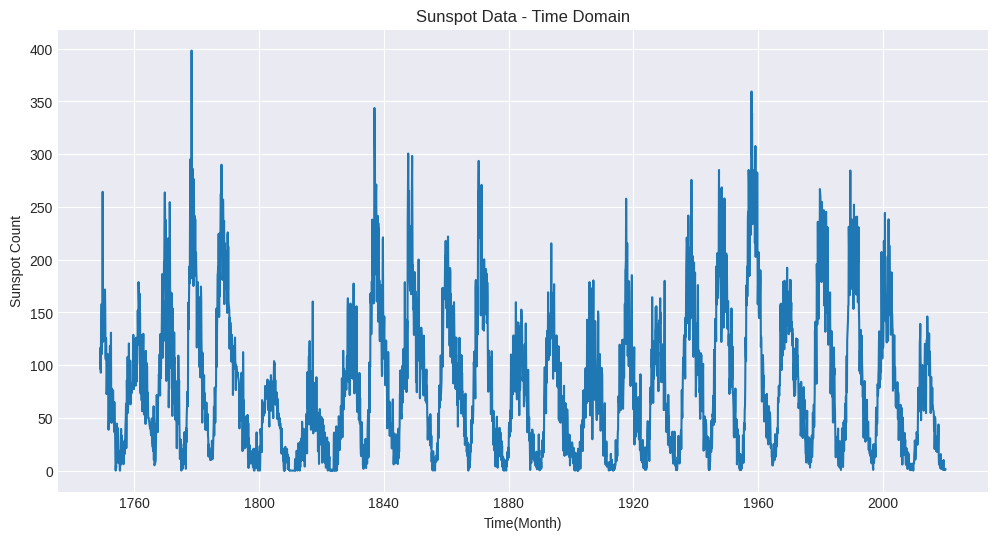

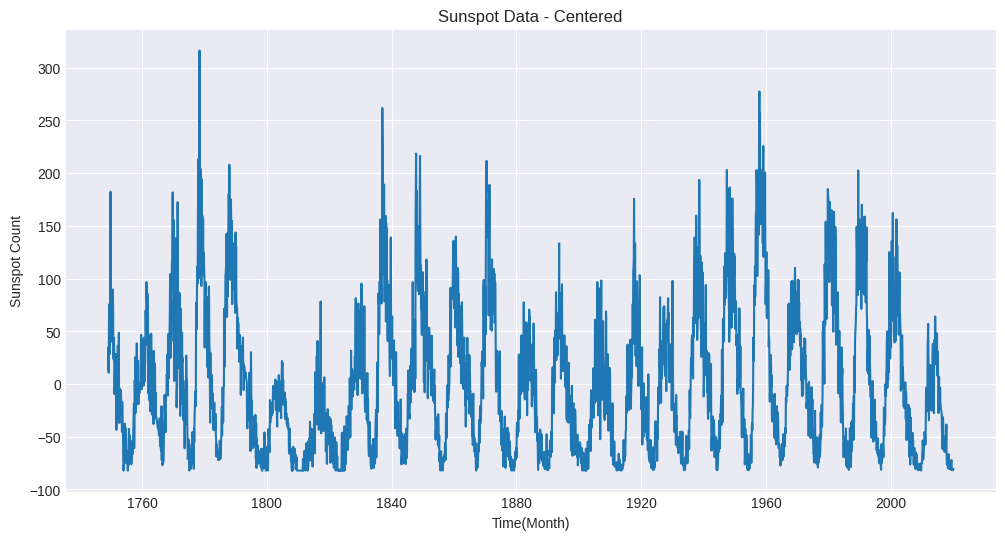

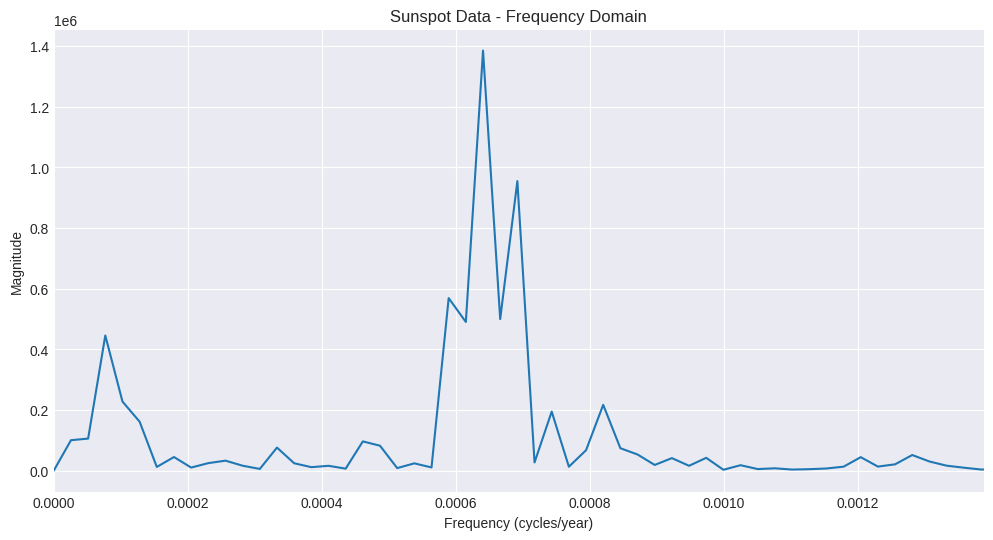

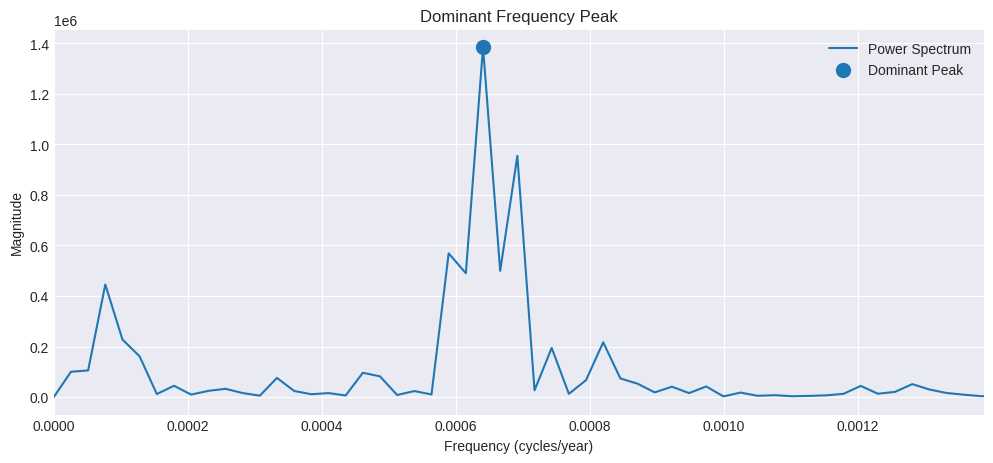

FFT PEAK DETECTION RESULT
Dominant Frequency            : 0.0006 cycles/year
Computed Solar Cycle Period   : 1560.96 years


In [1]:
# Import required scientific libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.widgets import Slider

# Set plot style for academic formatting
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# --- TASK 1: Load and plot the raw time-domain data ---
# 1. Load the CSV data using pandas
# Ensure the raw CSV is downloaded, as previous wget might have downloaded HTML
!wget -O sunspots.csv https://raw.githubusercontent.com/TR2Theo/fft-case-studies-template/main/data/sunspots.csv
df = pd.read_csv("sunspots.csv")

# 2. Extract the time array (t) and signal array (y)
time = pd.to_datetime(df["Date"])
y = df["Monthly Mean Total Sunspot Number"].values
# 3. Plot Sunspot Count vs. Time
# 4. Include appropriate labels, units, and a title.
plt.plot(time, y)
plt.title("Sunspot Data - Time Domain")
plt.xlabel("Time(Month)")
plt.ylabel("Sunspot Count")
plt.grid(True)
plt.show()

# --- TASK 2: Remove the DC component ---

# YOUR CODE HERE
# 1. Calculate the mean of the sunspot array.
Mean = np.mean(y)
y_centered = y - Mean
# 2. Create a new array: y_centered = y - mean
# 3. (Optional) Plot the centered data to verify it oscillates around zero.
plt.plot(time, y_centered)
plt.title("Sunspot Data - Centered")
plt.xlabel("Time(Month)")
plt.ylabel("Sunspot Count")
plt.grid(True)
plt.show()

# --- TASK 3: Compute the FFT and Power Spectrum ---

# YOUR CODE HERE
# 1. Define N (number of samples) and dt (sampling interval in years).
N = len(y)
dt = 12
# 2. Compute the FFT using np.fft.fft()
fft_result = np.fft.fft(y_centered)
# 3. Compute the frequency bins using np.fft.fftfreq()
freq_bins = np.fft.fftfreq(N, d=dt)
# 4. Calculate the positive magnitude spectrum (Power). Remember to only keep the positive half of the frequencies (up to the Nyquist limit).
positive_mask = freq_bins >= 0
positive_freq = freq_bins[positive_mask]
# Magnitude Spectrum
magnitude = np.abs(fft_result[positive_mask])
# Power Spectrum
power = magnitude**2
# ------------------------------------------------
# Optional: Normalize
# ------------------------------------------------
power = power / N

n_classes = 30

# interval frekuensi
bins = np.linspace(
    positive_freq.min(),
    positive_freq.max(),
    n_classes + 1
)

# menyimpan total power tiap kelas
class_power = []

# =========================================================
# CALCULATE TOTAL POWER EACH CLASS
# =========================================================

for i in range(n_classes):

    mask = (
        (positive_freq >= bins[i]) &
        (positive_freq < bins[i+1])
    )

    total_power = np.sum(power[mask])

    class_power.append(total_power)

class_power = np.array(class_power)

# =========================================================
# FIND DOMINANT CLASS
# =========================================================

dominant_idx = np.argmax(class_power)
upper_bound = bins[dominant_idx + 1]

# =========================================================
# PRINT RESULT
# =========================================================
# --- TASK 4: Visualize the Frequency Domain ---

# YOUR CODE HERE
# 1. Plot the power spectrum.
# 2. Clearly label the x-axis as "Frequency (cycles/year)" and y-axis as "Magnitude".
# 3. Use plt.xlim() to restrict the view to low frequencies where the solar cycle dominates.
plt.plot(positive_freq, power)
plt.xlim(0, upper_bound)
plt.title("Sunspot Data - Frequency Domain")
plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

# --- TASK 5: Programmatic peak detection ---

# =========================================================
# TASK 5: Programmatic Peak Detection
# =========================================================

# Ignore zero frequency to avoid DC peak
peak_index = np.argmax(power[1:]) + 1

# Dominant frequency
dominant_frequency = positive_freq[peak_index]

# Dominant period
dominant_period = 1 / dominant_frequency

# =========================================================
# OPTIONAL: Mark dominant peak on spectrum
# =========================================================

plt.figure(figsize=(12,5))

plt.plot(positive_freq, power, label='Power Spectrum')

plt.scatter(
    dominant_frequency,
    power[peak_index],
    s=100,
    label='Dominant Peak'
)

plt.xlim(0, upper_bound)

plt.title("Dominant Frequency Peak")
plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Magnitude")

plt.legend()
plt.grid(True)

plt.show()

# Print result
print("=================================================")
print("FFT PEAK DETECTION RESULT")
print("=================================================")

print(f"Dominant Frequency            : {dominant_frequency:.4f} cycles/year")
print(f"Computed Solar Cycle Period   : {dominant_period:.2f} years")

print("=================================================")